# EdgeEngine AWARE — running the simulator on recorded traces

The stochastic weather and soil models of the simulator are *models*. Before trusting a
policy trained on them, the least we can do is run it on **data those models never
generated**: an hourly year of irradiance, soil moisture, temperature, humidity and
rainfall of a real site, replayed by the trace-driven backends of
`edgeengine_aware.traces`.

What this notebook does:

1. loads a trace and looks at the seasons it contains (harvest, soil moisture, rain);
2. compares the **statistics** of the trace with those of the synthetic models the
   policies were trained on — where do they agree, where not;
3. evaluates the **baselines and the trained PPO policy** on the trace, season by season,
   with exactly the same protocol as `train_rl.ipynb` (same metrics, held-out seeds);
4. shows one replayed week in detail;
5. summarises what transfers and what does not.

> **Data.** The repository ships `data/traces/demo_liguria_2023_hourly.csv`, a **synthetic**
> stand-in generated by `tools/make_demo_trace.py` (astronomical clear-sky irradiance,
> Markov weather, a soil-water bucket, summer irrigation) so that everything runs offline.
> It is deliberately *not* the simulator's own model, but it is not measured data either.
> To use the real ERA5-Land reanalysis for the same site run
> `python tools/fetch_open_meteo.py --lat 44.05 --lon 8.21 --start 2023-01-01 --end 2023-12-31`
> (Open-Meteo archive, CC BY 4.0); the notebook picks up `albenga_2023_hourly.csv`
> automatically when it exists. Your own logger data works too — see `Trace.from_csv`.

## 0. Setup

In [1]:
%matplotlib inline
import json, os, time, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import edgeengine_aware as eea
from edgeengine_aware import (EdgeEngineAwareEnv, NodeProfile, PeriodicPolicy, RuleBasedParams,
                              RuleBasedPolicy, default_config, get_scenario, run_episode)
from edgeengine_aware.traces import Trace, TraceDrivenEnv
from edgeengine_aware.rl import NumpyMLPPolicy, evaluate, summarize
from edgeengine_aware.deployment import PolicyBundle

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#e34948"]

ROOT = Path(eea.__file__).resolve().parents[1]
DATA = ROOT / "data" / "traces"
RUNS = ROOT / "examples" / "rl_runs"
DAY = 86400.0
print("EdgeEngine AWARE", eea.__version__)

EdgeEngine AWARE 0.3.0


## 1. The trace

`Trace.from_csv` reads the CSV written by the fetch / demo scripts: `# key=value` provenance
lines, then one row per hour. Each column carries a *kind*: `instant` values (soil moisture,
temperature) are interpolated linearly; `preceding_mean` values (irradiance, precipitation,
as weather archives deliver them) are piecewise constant over the hour that ends at the
timestamp. Time is in seconds since the first local midnight, so the simulator's clock and
the trace's sun agree.

In [2]:
real = DATA / "albenga_2023_hourly.csv"
demo = DATA / "demo_liguria_2023_hourly.csv"
TRACE_PATH = real if real.exists() else demo
trace = Trace.from_csv(TRACE_PATH)
IS_DEMO = "SYNTHETIC" in trace.meta.get("site", "").upper()
print(trace.describe())
if IS_DEMO:
    print("\n*** This is the synthetic demo trace, not measured data — see the note at the top. ***")

Trace: 8761 samples, 365 days, step 1.00 h
  site = SYNTHETIC demo trace, Liguria-like coastal site (NOT measured data)
  latitude = 44.05
  longitude = 8.21
  source = tools/make_demo_trace.py seed=2023 (stand-in for the Open-Meteo archive)
  utc_offset_h = 1.0
  start_local = 2023-01-01T00:00
  unit:shortwave_radiation = W/m²
  unit:soil_moisture_0_to_7cm = m³/m³
  unit:temperature_2m = °C
  unit:relative_humidity_2m = %
  unit:precipitation = mm
  file = demo_liguria_2023_hourly.csv
  shortwave_radiation          [preceding_mean] min     0.000  mean   127.570  max   960.800
  soil_moisture_0_to_7cm       [instant       ] min     0.094  mean     0.283  max     0.483
  temperature_2m               [instant       ] min    -4.660  mean    15.472  max    33.310
  relative_humidity_2m         [instant       ] min    35.700  mean    68.744  max   100.000
  precipitation                [preceding_mean] min     0.000  mean     0.099  max    30.120

*** This is the synthetic demo trace, not m

The panel is the one of the default hardware profile (5 mW at 1000 W/m², 60 % converter
efficiency), so the daily harvest in joules is directly comparable with the simulator's
"~55 J on a nominal day" and with the node's daily budget: 200 µW baseline = 17 J/day, plus
whatever sensing and transmission the policy decides.

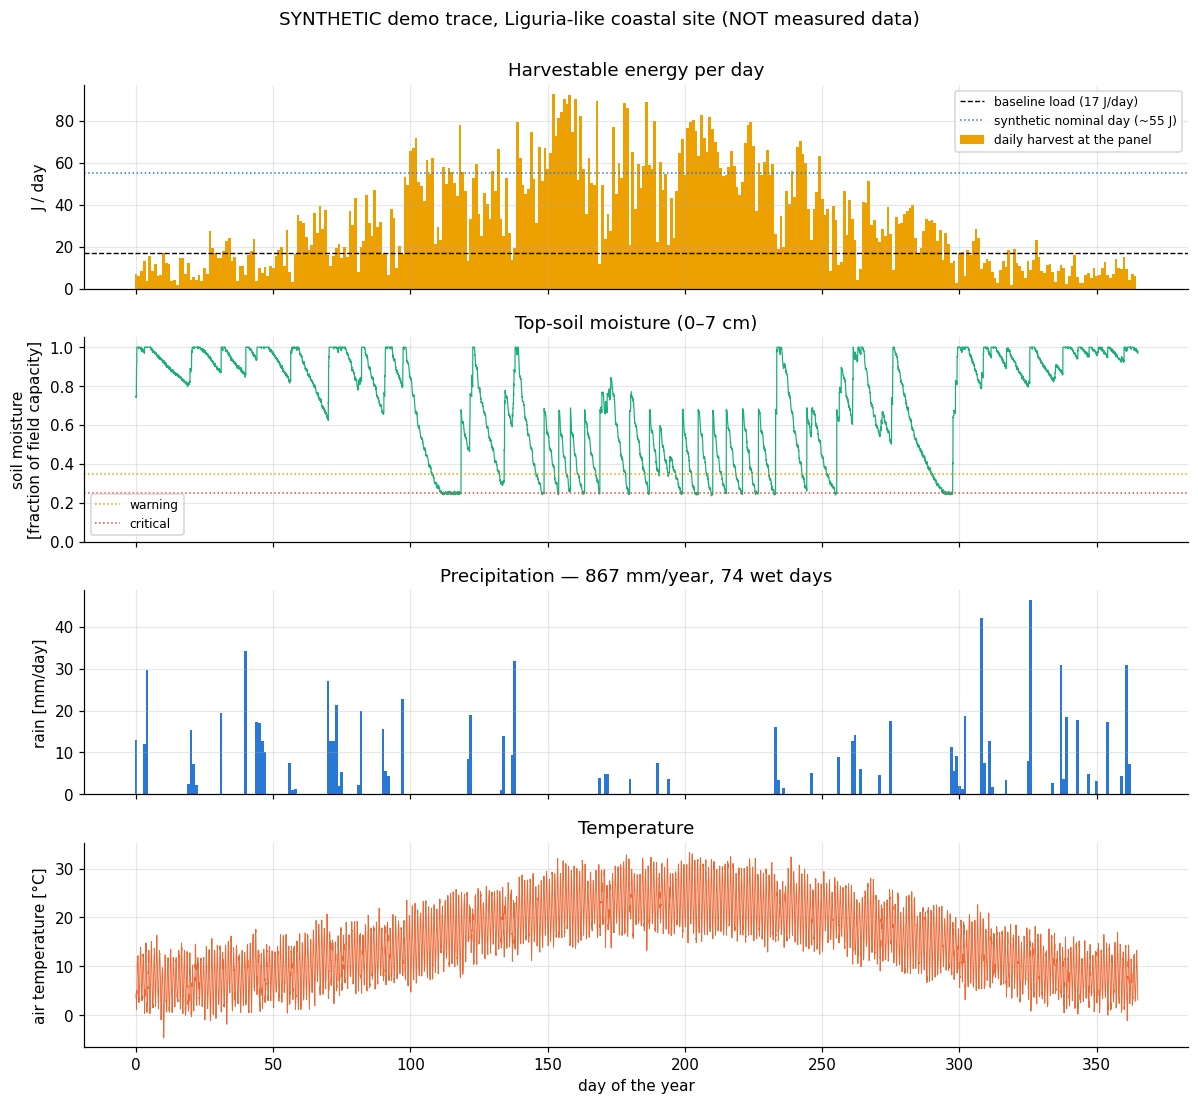

,harvest J/day,days below baseline,time in warning zone,rain mm
Jan,9.89,29,0.00,82.29
Feb,13.44,20,0.00,120.42
Mar,26.90,6,0.00,103.61
Apr,43.60,5,0.35,48.12
May,45.50,2,0.15,83.54
Jun,62.93,1,0.29,17.33
Jul,60.80,0,0.31,11.02
Aug,53.76,0,0.30,20.74
Sep,33.58,5,0.17,51.47
Oct,24.65,8,0.25,65.52


In [3]:
cfg0 = default_config()
panel = cfg0.harvesting.max_power_w * cfg0.harvesting.efficiency / 1000.0   # W per (W/m²)
ghi_day = trace.daily_means("shortwave_radiation")                            # W/m², per day
harvest_day_j = ghi_day * panel * DAY
theta = trace.columns["soil_moisture_0_to_7cm"].values / 0.40                 # fraction of field capacity
t_days = trace.time_s / DAY
rain = trace.columns["precipitation"].values
rain_day = np.array([trace.interval_sum("precipitation", k * DAY, (k + 1) * DAY) for k in range(trace.n_days)])
baseline_day_j = cfg0.mcu.baseline_power_w * DAY

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
ax = axes[0]
ax.bar(np.arange(trace.n_days), harvest_day_j, width=1.0, color=PALETTE[3], label="daily harvest at the panel")
ax.axhline(baseline_day_j, color="k", ls="--", lw=0.9, label=f"baseline load ({baseline_day_j:.0f} J/day)")
ax.axhline(55, color=PALETTE[0], ls=":", lw=1.0, label="synthetic nominal day (~55 J)")
ax.set_ylabel("J / day"); ax.legend(loc="upper right", fontsize=8); ax.set_title("Harvestable energy per day")
ax = axes[1]
ax.plot(t_days, np.clip(theta, 0, 1.0), color=PALETTE[2], lw=0.8)
ax.axhline(cfg0.agriculture.warning_threshold, color=PALETTE[3], ls=":", lw=1, label="warning")
ax.axhline(cfg0.agriculture.critical_threshold, color=PALETTE[6], ls=":", lw=1, label="critical")
ax.set_ylabel("soil moisture\n[fraction of field capacity]"); ax.set_ylim(0, 1.05); ax.legend(loc="lower left", fontsize=8)
ax.set_title("Top-soil moisture (0–7 cm)")
ax = axes[2]
ax.bar(np.arange(trace.n_days), rain_day, width=1.0, color=PALETTE[0])
ax.set_ylabel("rain [mm/day]"); ax.set_title(f"Precipitation — {rain_day.sum():.0f} mm/year, {int((rain_day > 0.2).sum())} wet days")
ax = axes[3]
ax.plot(t_days, trace.columns["temperature_2m"].values, color=PALETTE[1], lw=0.6)
ax.set_ylabel("air temperature [°C]"); ax.set_xlabel("day of the year"); ax.set_title("Temperature")
fig.suptitle(f"{trace.meta.get('site', TRACE_PATH.name)}", y=1.0)
fig.tight_layout(); plt.show()

months = pd.date_range("2023-01-01", periods=12, freq="MS")
tbl = pd.DataFrame({
    "harvest J/day": [harvest_day_j[m.dayofyear - 1:(m + pd.offsets.MonthEnd()).dayofyear].mean() for m in months],
    "days below baseline": [int((harvest_day_j[m.dayofyear - 1:(m + pd.offsets.MonthEnd()).dayofyear] < baseline_day_j).sum()) for m in months],
    "time in warning zone": [(theta[(t_days >= m.dayofyear - 1) & (t_days < (m + pd.offsets.MonthEnd()).dayofyear)] < 0.35).mean() for m in months],
    "rain mm": [rain_day[m.dayofyear - 1:(m + pd.offsets.MonthEnd()).dayofyear].sum() for m in months],
}, index=[m.strftime("%b") for m in months])
tbl.round(2)

## 2. Synthetic models vs. trace

The policies were trained on the stochastic models with the `default` and `cloudy_week`
scenarios (among others). How different is the trace? We compare, over many simulated days,
the distribution of **daily harvested energy** and of the **daily change of soil moisture**
— the two quantities that drive the trade-off the policy has to make.

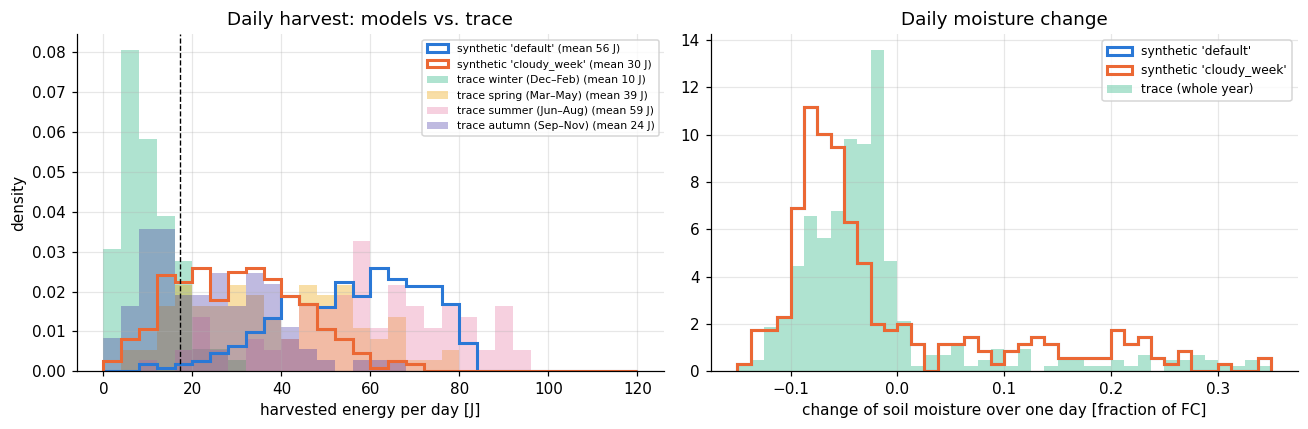

fraction of time in the warning/critical zones — synthetic default: 0.22, trace summer: 0.30, trace winter: 0.00


In [4]:
def synthetic_days(scenario, n_episodes=40, seed0=5000):
    cfg = get_scenario(scenario, randomize=False)
    cfg.time.episode_days = 7
    env = EdgeEngineAwareEnv(cfg)
    harvest, dtheta, zone_warn = [], [], []
    for ep in range(n_episodes):
        env.reset(seed=seed0 + ep)
        h_day, th_day, warn = 0.0, [], []
        for step in range(env.max_steps):
            _, _, term, trunc, info = env.step(np.array([0, 0]))
            h_day += info["harvested_energy_j"]
            th_day.append(info["ground_truth"]["soil_moisture"]); warn.append(info["ground_truth"]["zone"] >= 1)
            if (step + 1) % 96 == 0:
                harvest.append(h_day); dtheta.append(th_day[-1] - th_day[0]); zone_warn.append(np.mean(warn))
                h_day, th_day, warn = 0.0, [], []
            if term or trunc:
                break
    env.close()
    return np.array(harvest), np.array(dtheta), np.array(zone_warn)

syn = {s: synthetic_days(s) for s in ("default", "cloudy_week")}
trace_dtheta = np.array([theta[min(len(theta) - 1, (k + 1) * 24)] - theta[k * 24] for k in range(trace.n_days)])
seasons = {"winter (Dec–Feb)": lambda d: (d < 59) | (d >= 334), "spring (Mar–May)": lambda d: (59 <= d) & (d < 151),
           "summer (Jun–Aug)": lambda d: (151 <= d) & (d < 243), "autumn (Sep–Nov)": lambda d: (243 <= d) & (d < 334)}
days_idx = np.arange(trace.n_days)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(0, 120, 31)
for i, (s, (h, _, _)) in enumerate(syn.items()):
    axes[0].hist(h, bins=bins, density=True, histtype="step", lw=2, color=PALETTE[i], label=f"synthetic '{s}' (mean {h.mean():.0f} J)")
for i, (name, sel) in enumerate(seasons.items()):
    h = harvest_day_j[sel(days_idx)]
    axes[0].hist(h, bins=bins, density=True, alpha=0.35, color=PALETTE[2 + i], label=f"trace {name} (mean {h.mean():.0f} J)")
axes[0].axvline(baseline_day_j, color="k", ls="--", lw=0.9)
axes[0].set_xlabel("harvested energy per day [J]"); axes[0].set_ylabel("density"); axes[0].legend(fontsize=7); axes[0].set_title("Daily harvest: models vs. trace")
bins = np.linspace(-0.15, 0.35, 41)
for i, (s, (_, d, _)) in enumerate(syn.items()):
    axes[1].hist(d, bins=bins, density=True, histtype="step", lw=2, color=PALETTE[i], label=f"synthetic '{s}'")
axes[1].hist(trace_dtheta, bins=bins, density=True, alpha=0.35, color=PALETTE[2], label="trace (whole year)")
axes[1].set_xlabel("change of soil moisture over one day [fraction of FC]"); axes[1].legend(fontsize=8); axes[1].set_title("Daily moisture change")
fig.tight_layout(); plt.show()

print(f"fraction of time in the warning/critical zones — synthetic default: {syn['default'][2].mean():.2f}, "
      f"trace summer: {(theta[seasons['summer (Jun–Aug)'](t_days)] < 0.35).mean():.2f}, trace winter: {(theta[seasons['winter (Dec–Feb)'](t_days)] < 0.35).mean():.2f}")

The synthetic `default` scenario is a perpetual mild season: every day harvests more than
the baseline load and the soil dries at a steady pace, occasionally reset by rain or
irrigation. The trace has **seasons**: winter days may harvest less than the node consumes
just to stay alive, summer days harvest more than the battery can absorb, and the top soil
only enters the stress zones during the growing season. `cloudy_week` is the scenario that
comes closest to winter — which is why it was included in training.

## 3. Evaluating the policies on the trace

We keep the protocol of `train_rl.ipynb`: deterministic policies, 7-day episodes, 10 held-out
seeds per case, the same `EvalRow` metrics. Each season is a sub-trace (`Trace.slice_days`);
the seed picks a random 7-day window inside the season (`TraceDrivenEnv` reports it in
`info["trace_start_day"]`). The PPO policy is the exported `PolicyBundle` of the RL notebook,
executed with the numpy runtime — no PyTorch needed.

In [5]:
cfg = default_config()
PROFILE = NodeProfile.from_config(cfg)
policies = {
    "rule-based": lambda: RuleBasedPolicy(RuleBasedParams(), PROFILE),
    "periodic 1h": lambda: PeriodicPolicy(period_steps=4, sensing_level=2, tx=2),
    "periodic 3h": lambda: PeriodicPolicy(period_steps=12, sensing_level=2, tx=3),
}
bundle_path = next((p for p in [RUNS / "seeds_long" / "ppo_seed0_bundle.json", RUNS / "ppo_default_bundle.json", ROOT / "examples" / "bundles" / "ppo_default.json"] if p.exists()), None)
if bundle_path is not None:
    bundle = PolicyBundle.load(bundle_path)
    policies["PPO (exported)"] = lambda: NumpyMLPPolicy(bundle.model)
    print("PPO bundle:", bundle_path.relative_to(ROOT), "—", bundle.metadata.get("notes", ""))
else:
    print("no PPO bundle found (examples/bundles/ppo_default.json or examples/rl_runs/*) — evaluating the baselines only")

season_days = {"winter": (0, 59), "spring": (59, 151), "summer": (151, 243), "autumn": (243, 334)}
envs = {}
for name, (d0, d1) in season_days.items():
    sub = trace.slice_days(d0, d1 - d0)
    envs[f"trace {name}"] = TraceDrivenEnv(sub, cfg)
SEEDS = range(1000, 1010)

t0 = time.time()
rows = evaluate(policies, envs=envs, seeds=SEEDS)
rows += evaluate(policies, scenarios=["default", "cloudy_week"], seeds=SEEDS)
print(f"{len(rows)} episodes in {time.time() - t0:.0f} s")
df = pd.DataFrame([r.as_dict() for r in rows])

PPO bundle: examples/rl_runs/ppo_default_bundle.json — PPO 2,000,000 steps, domain randomisation on


240 episodes in 45 s


In [6]:
metrics = {"reward": "episode return", "utility": "application utility", "n_delivered": "packets delivered",
           "min_soc": "minimum SoC", "depletions": "brown-outs", "aoi_h": "mean AoI [h]"}
order = list(envs) + ["default", "cloudy_week"]
summary = df.groupby(["scenario", "policy"])[list(metrics)].agg(["mean", "std"]).reindex(order, level=0)
summary.round(2)

reward         utility        n_delivered         \
                               mean     std    mean    std        mean    std   
scenario     policy                                                             
trace winter PPO (exported)  -14.25   47.70   58.19   0.82        51.2   3.55   
             periodic 1h    -411.50  132.87   53.39   6.46        79.0  12.96   
             periodic 3h     -45.25   69.46   57.82   1.28        52.7   3.71   
             rule-based       13.41   19.27   58.12   1.28        40.5   3.54   
trace spring PPO (exported)   55.68   47.22   79.29  50.99        69.5  12.55   
             periodic 1h      32.27   75.54   82.59  61.15       122.7  10.09   
             periodic 3h      56.84   44.54   78.70  49.62        55.1   0.99   
             rule-based       58.80   50.24   80.54  54.39        77.2  27.88   
trace summer PPO (exported)   84.76   18.18  112.63  19.00        97.5  19.26   
             periodic 1h      81.91   21.01  112.33  21.32       124.6  10.64   
             periodic 3h      85.25   17.93  109.87  18.87        55.1   0.99   
             rule-based       89.17   18.98  115.50  19.92       120.3  15.78   
trace autumn PPO (exported)   55.10   35.82   80.86  36.12        64.6   8.64   
             periodic 1h     -80.01  165.02   80.87  40.31       113.0  18.74   
             periodic 3h      52.78   40.76   81.10  37.93        55.1   0.99   
             rule-based       53.47   29.59   81.15  37.70        65.1  21.72   
default      PPO (exported)   70.36   30.61   98.37  32.58        94.9  10.95   
             periodic 1h      68.37   30.71   98.46  32.52       124.6  10.64   
             periodic 3h      72.21   29.37   96.60  32.36        55.1   0.99   
             rule-based       75.28   30.65  102.28  34.08       125.1  24.04   
cloudy_week  PPO (exported)   68.73   34.61   96.51  31.57        62.6   5.68   
             periodic 1h     -26.73  117.71   95.05  32.55       115.3  14.58   
             periodic 3h      66.84   37.49   96.60  32.36        55.1   0.99   
             rule-based       60.73   21.61   97.16  31.15        76.1  21.52   

                            min_soc       depletions         aoi_h        
                               mean   std       mean    std   mean   std  
scenario     policy                                                       
trace winter PPO (exported)    0.09  0.07        1.5   4.74   2.32  0.66  
             periodic 1h       0.00  0.00      111.8  52.64  10.63  6.11  
             periodic 3h       0.04  0.06        7.8  22.64   2.15  0.79  
             rule-based        0.14  0.08        0.0   0.00   2.56  0.31  
trace spring PPO (exported)    0.38  0.07        0.0   0.00   1.63  0.22  
             periodic 1h       0.21  0.15        0.0   0.00   1.43  0.36  
             periodic 3h       0.40  0.07        0.0   0.00   1.68  0.07  
             rule-based        0.40  0.06        0.0   0.00   1.54  0.38  
trace summer PPO (exported)    0.47  0.01        0.0   0.00   1.31  0.17  
             periodic 1h       0.43  0.06        0.0   0.00   1.38  0.37  
             periodic 3h       0.47  0.01        0.0   0.00   1.68  0.07  
             rule-based        0.47  0.01        0.0   0.00   0.99  0.14  
trace autumn PPO (exported)    0.31  0.13        0.0   0.00   1.75  0.14  
             periodic 1h       0.08  0.11       27.9  44.62   4.09  5.46  
             periodic 3h       0.30  0.16        0.0   0.00   1.68  0.07  
             rule-based        0.33  0.14        0.0   0.00   1.87  0.43  
default      PPO (exported)    0.47  0.01        0.0   0.00   1.33  0.08  
             periodic 1h       0.44  0.03        0.0   0.00   1.38  0.37  
             periodic 3h       0.47  0.00        0.0   0.00   1.68  0.07  
             rule-based        0.46  0.03        0.0   0.00   0.98  0.08  
cloudy_week  PPO (exported)    0.29  0.09        0.0   0.00   1.81  0.12  
             periodic 1h       0.09  0.08

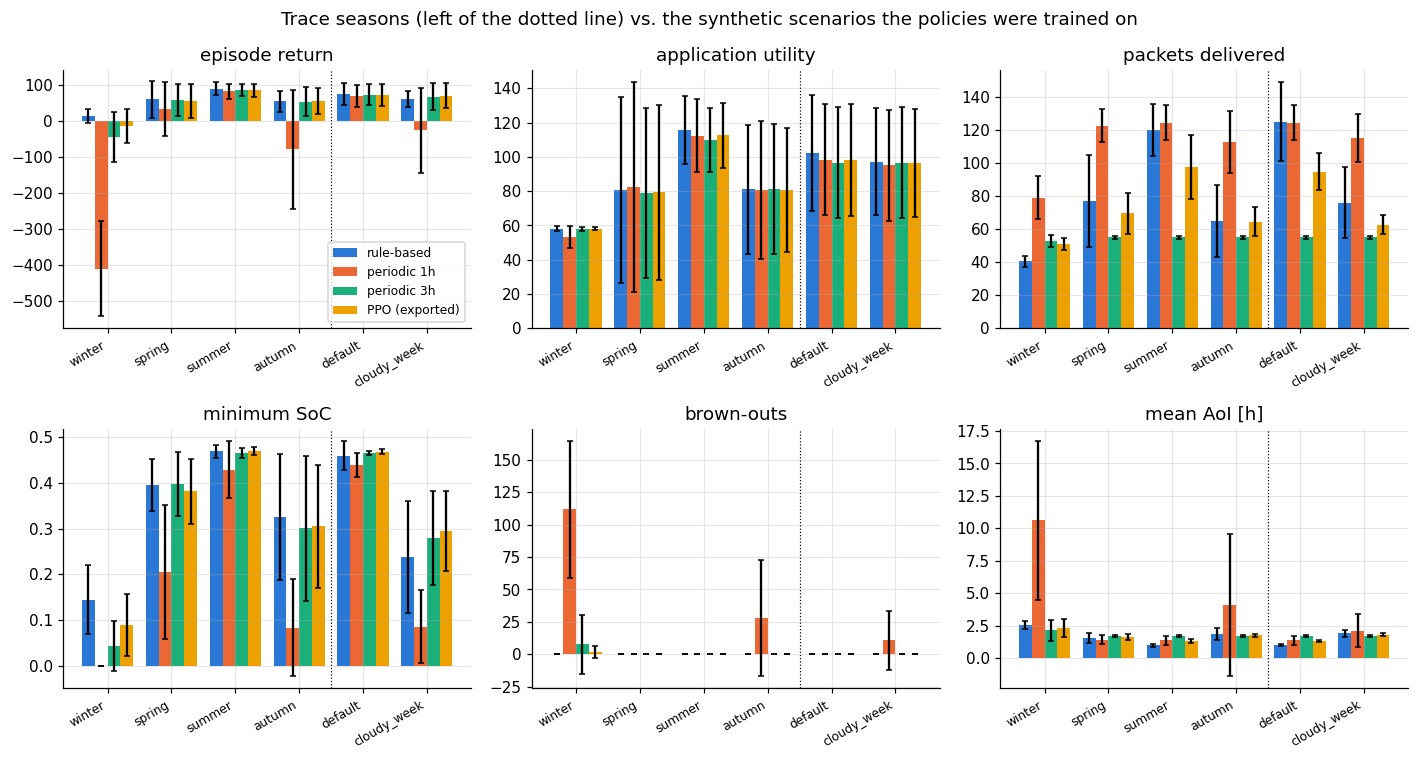

In [7]:
pol_order = list(policies)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (m, label) in zip(axes.ravel(), metrics.items()):
    w = 0.8 / len(pol_order)
    for j, p in enumerate(pol_order):
        sub = df[df.policy == p].groupby("scenario")[m].agg(["mean", "std"]).reindex(order)
        x = np.arange(len(order)) + (j - (len(pol_order) - 1) / 2) * w
        ax.bar(x, sub["mean"], width=w, yerr=sub["std"], color=PALETTE[j], capsize=2, label=p)
    ax.set_xticks(np.arange(len(order))); ax.set_xticklabels([o.replace("trace ", "") for o in order], rotation=30, ha="right", fontsize=8)
    ax.set_title(label); ax.axvline(len(envs) - 0.5, color="k", lw=0.8, ls=":")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Trace seasons (left of the dotted line) vs. the synthetic scenarios the policies were trained on")
fig.tight_layout(); plt.show()

How much of the ranking established on the synthetic scenarios survives? The table below
shows, per season, the return of each policy **relative to the rule-based controller** — the
number that decides whether a learned policy is worth deploying.

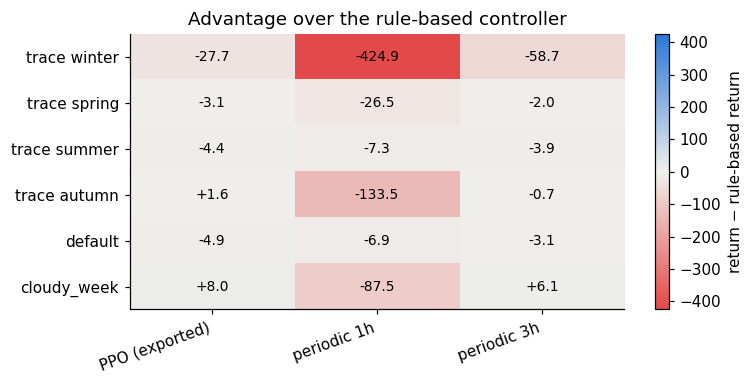

In [8]:
piv = df.pivot_table(index="scenario", columns="policy", values="reward", aggfunc="mean").reindex(order)
rel = piv.sub(piv["rule-based"], axis=0).drop(columns="rule-based")
fig, ax = plt.subplots(figsize=(7, 3.6))
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
cmap = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
lim = float(np.nanmax(np.abs(rel.values))) or 1.0
im = ax.imshow(rel.values, cmap=cmap, norm=TwoSlopeNorm(0, -lim, lim), aspect="auto")
ax.set_xticks(range(rel.shape[1])); ax.set_xticklabels(rel.columns, rotation=20, ha="right")
ax.set_yticks(range(rel.shape[0])); ax.set_yticklabels(rel.index)
for i in range(rel.shape[0]):
    for j in range(rel.shape[1]):
        ax.text(j, i, f"{rel.values[i, j]:+.1f}", ha="center", va="center", fontsize=9)
ax.grid(False); plt.colorbar(im, ax=ax, label="return − rule-based return"); ax.set_title("Advantage over the rule-based controller")
fig.tight_layout(); plt.show()

## 4. One replayed week in detail

A summer week from the trace, driven by the rule-based controller (and by the PPO policy when
available). The top panel shows what the replay provides — recorded irradiance turned into
harvested energy — and what the node makes of it.

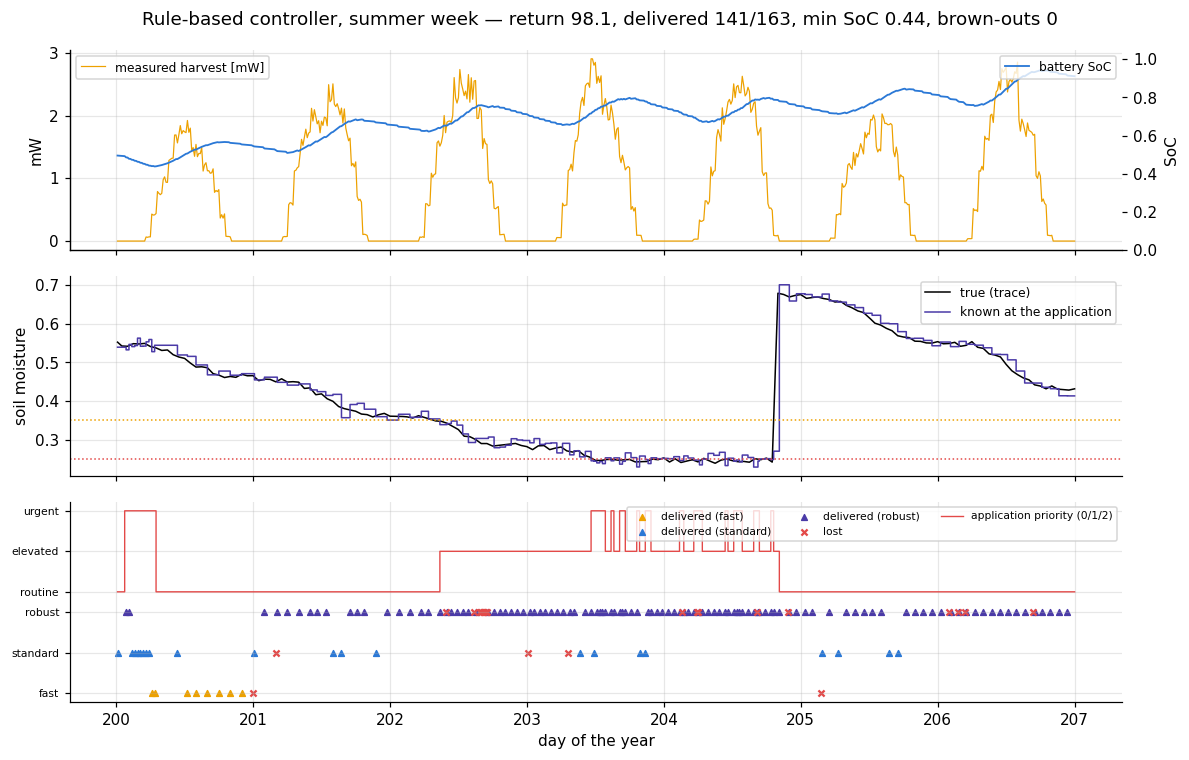

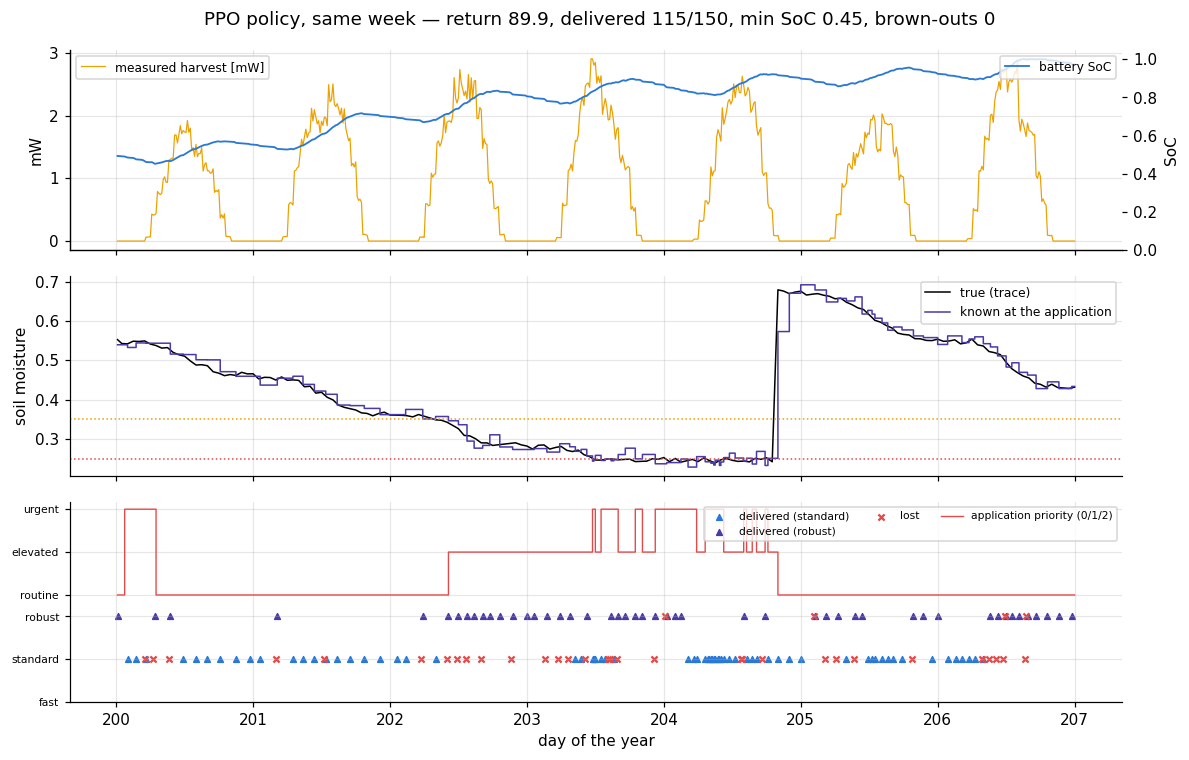

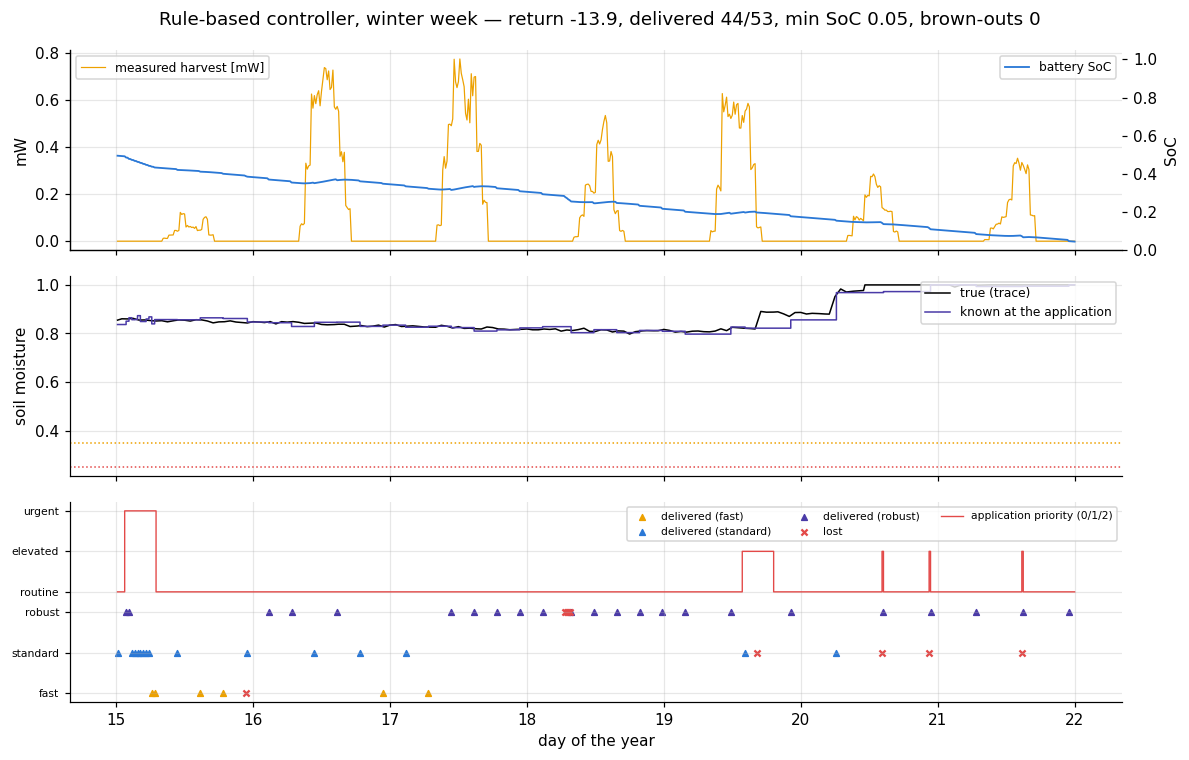

In [9]:
def replay_week(policy_factory, start_day, title):
    env = TraceDrivenEnv(trace, cfg, start_day=start_day)
    res = run_episode(env, policy_factory(), seed=1000)
    log, m = env.log, env.metrics
    t = np.asarray(log.time_s) / DAY + start_day
    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
    axes[0].plot(t, np.asarray(log.harvest_power_w) * 1e3, color=PALETTE[3], lw=0.8, label="measured harvest [mW]")
    axes[0].set_ylabel("mW"); axes[0].legend(loc="upper left", fontsize=8)
    ax2 = axes[0].twinx(); ax2.plot(t, log.soc, color=PALETTE[0], lw=1.2, label="battery SoC"); ax2.set_ylim(0, 1.05); ax2.set_ylabel("SoC"); ax2.grid(False); ax2.legend(loc="upper right", fontsize=8)
    axes[1].plot(t, log.true_moisture, color="k", lw=1, label="true (trace)")
    axes[1].plot(t, log.app_moisture, color=PALETTE[5], lw=1, drawstyle="steps-post", label="known at the application")
    axes[1].axhline(cfg.agriculture.warning_threshold, color=PALETTE[3], ls=":", lw=1); axes[1].axhline(cfg.agriculture.critical_threshold, color=PALETTE[6], ls=":", lw=1)
    axes[1].set_ylabel("soil moisture"); axes[1].legend(fontsize=8, loc="upper right")
    att, suc, mode = np.asarray(log.tx_attempt), np.asarray(log.tx_success), np.asarray(log.tx_mode)
    for k, (nm, c) in enumerate(zip(("fast", "standard", "robust"), ("#eda100", "#2a78d6", "#4a3aa7"))):
        sel = (att == 1) & (suc == 1) & (mode == k)
        if sel.any(): axes[2].scatter(t[sel], np.full(sel.sum(), k), marker="^", s=14, color=c, label=f"delivered ({nm})")
    fail = (att == 1) & (suc == 0)
    if fail.any(): axes[2].scatter(t[fail], mode[fail], marker="x", s=16, color=PALETTE[6], label="lost")
    axes[2].step(t, np.asarray(log.priority) - 0.5 + 3, where="post", color=PALETTE[6], lw=0.9, label="application priority (0/1/2)")
    axes[2].set_yticks([0, 1, 2, 2.5, 3.5, 4.5]); axes[2].set_yticklabels(["fast", "standard", "robust", "routine", "elevated", "urgent"], fontsize=7)
    axes[2].legend(fontsize=7, ncol=3, loc="upper right"); axes[2].set_xlabel("day of the year")
    fig.suptitle(f"{title} — return {res.total_reward:.1f}, delivered {m.n_successful_transmissions}/{m.n_transmissions}, min SoC {m.min_battery_soc:.2f}, brown-outs {m.battery_depletion_events}")
    fig.tight_layout(); plt.show()
    env.close()

SUMMER_START = 200
replay_week(policies["rule-based"], SUMMER_START, "Rule-based controller, summer week")
if "PPO (exported)" in policies:
    replay_week(policies["PPO (exported)"], SUMMER_START, "PPO policy, same week")
replay_week(policies["rule-based"], 15, "Rule-based controller, winter week")

## 5. Findings

In [10]:
def mean_of(policy, scenario, metric="reward"):
    v = df[(df.policy == policy) & (df.scenario == scenario)][metric]
    return float(v.mean()) if len(v) else float("nan")

lines = []
rb_w, rb_s = mean_of("rule-based", "trace winter"), mean_of("rule-based", "trace summer")
lines.append(f"* Rule-based return: winter {rb_w:.1f} vs summer {rb_s:.1f} (synthetic default {mean_of('rule-based', 'default'):.1f}, cloudy_week {mean_of('rule-based', 'cloudy_week'):.1f}).")
lines.append(f"* Periodic 1h in winter: min SoC {mean_of('periodic 1h', 'trace winter', 'min_soc'):.2f}, brown-outs {mean_of('periodic 1h', 'trace winter', 'depletions'):.1f} per week — the fixed duty cycle that is fine in summer is not sustainable on winter harvest.")
if "PPO (exported)" in policies:
    for s in ["trace winter", "trace spring", "trace summer", "trace autumn", "default", "cloudy_week"]:
        d = mean_of("PPO (exported)", s) - mean_of("rule-based", s)
        lines.append(f"* PPO vs rule-based on {s}: {d:+.1f} return ({mean_of('PPO (exported)', s, 'n_delivered'):.0f} vs {mean_of('rule-based', s, 'n_delivered'):.0f} packets, min SoC {mean_of('PPO (exported)', s, 'min_soc'):.2f} vs {mean_of('rule-based', s, 'min_soc'):.2f}).")
print("\n".join(lines))
if IS_DEMO:
    print("\nReminder: these numbers come from the synthetic demo trace. Fetch the archive data to draw conclusions about the site.")

* Rule-based return: winter 13.4 vs summer 89.2 (synthetic default 75.3, cloudy_week 60.7).
* Periodic 1h in winter: min SoC 0.00, brown-outs 111.8 per week — the fixed duty cycle that is fine in summer is not sustainable on winter harvest.
* PPO vs rule-based on trace winter: -27.7 return (51 vs 40 packets, min SoC 0.09 vs 0.14).
* PPO vs rule-based on trace spring: -3.1 return (70 vs 77 packets, min SoC 0.38 vs 0.40).
* PPO vs rule-based on trace summer: -4.4 return (98 vs 120 packets, min SoC 0.47 vs 0.47).
* PPO vs rule-based on trace autumn: +1.6 return (65 vs 65 packets, min SoC 0.31 vs 0.33).
* PPO vs rule-based on default: -4.9 return (95 vs 125 packets, min SoC 0.47 vs 0.46).
* PPO vs rule-based on cloudy_week: +8.0 return (63 vs 76 packets, min SoC 0.29 vs 0.24).

Reminder: these numbers come from the synthetic demo trace. Fetch the archive data to draw conclusions about the site.


**What to take from this notebook**

* The trace-driven environment exposes exactly the same observation and action spaces as the
  synthetic one — a policy or a controller cannot tell them apart, so it is the right harness
  for *evaluating* transfer and, when enough seasons are recorded, for *training* on real
  weather (`TraceDrivenEnv` is a Gymnasium environment like any other; wrap it in a
  `MixedScenarioEnv`-style mixture with the synthetic scenarios to keep the variety).
* Winter is the regime the synthetic scenarios under-represent: multi-day stretches in which
  the harvest is below the baseline load. A controller must ration *sensing and radio* against
  a slowly draining battery for a week, not for a cloudy day. This is where the rule-based
  controller's economy modes and the learned policies should be compared most carefully — and
  where the `cloudy_week` scenario should be made harsher if the transfer gap is large.
* Summer is energy-rich but *information-rich* too: the top soil crosses the stress thresholds
  every few days between irrigations, so the priority-driven reporting matters more than
  energy management.
* Next steps: (1) replace the demo with the real archive (`tools/fetch_open_meteo.py`) and
  with your own logger data when available; (2) add a `winter` synthetic scenario calibrated on
  the trace statistics of section 2; (3) train on a mixture of synthetic scenarios and
  trace seasons and check that nothing is lost on the synthetic test set.